# Evaluation of the Inaccuracy class

In [1]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_digits

import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

from nescience.inaccuracy import Inaccuracy

In [2]:
rcParams['figure.figsize'] = 10, 5

## Inaccuracy of a Model

The following example shows how inaccuracy can be used to evaluate the results of a trained model.

In [3]:
X, y = load_digits(return_X_y=True)
tree = DecisionTreeClassifier(min_samples_leaf=5)
tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [4]:
inacc = Inaccuracy(y_type="categorical")
inacc.fit(X, y)
inacc.inaccuracy_model(tree)

0.17107622551030005

We can also work directly with the set of predictions, instead of using the model. This allow us to compute the inaccuracy of models not implemented by scikit-learn.

In [5]:
pred = tree.predict(X)
inacc.inaccuracy_predictions(pred)

0.17107622551030005

## Compare score with inaccuracy

Train a collection of decision tree classifers with different levels of depth, compute a classical score and the new inaccuracy metric, and compare results.

In [6]:
X, y = load_digits(return_X_y=True)
inacc = Inaccuracy(y_type="categorical")
inacc.fit(X, y)

,y_type,'categorical'
,n_bins,'auto'
,min_samples_per_cell,5
,min_bins,2
,max_bins,None
,missing,'raise'
,base,2.0
,correction,'none'
,alpha,0.5
,alphabet_size,None


In [11]:
scores       = list()
inaccuracies = list()

for i in range(1, 20):
    
    tree = DecisionTreeClassifier(max_depth=i, random_state=42)
    tree.fit(X, y)
    
    scores.append(1 - tree.score(X, y))
    inaccuracies.append(inacc.inaccuracy_model(tree))

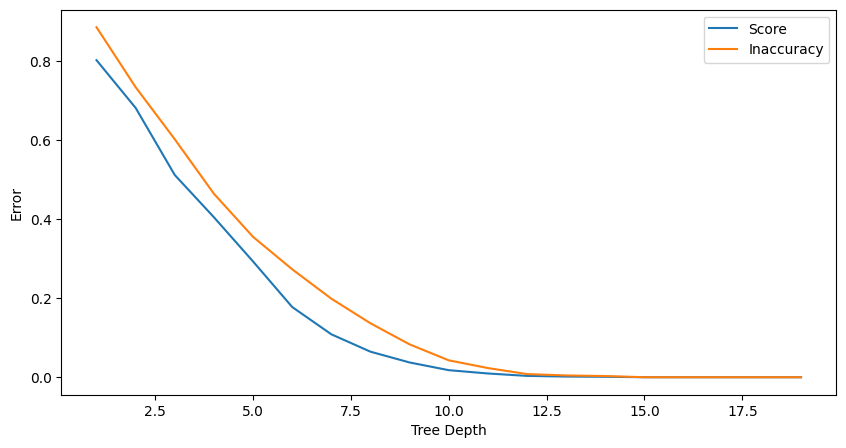

In [12]:
plt.plot(range(1,20), scores, label="Score")
plt.plot(range(1,20), inaccuracies, label="Inaccuracy")
plt.ylabel("Error")
plt.xlabel("Tree Depth")
plt.legend()
plt.show()

## Adding errors

Study the behavior of score and inaccuracy when we introduce errors in the dataset.

In [13]:
tree = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree.fit(X, y)
inacc.fit(X, y)
inacc.inaccuracy_model(tree)

0.17422494529090926

In [14]:
1 - tree.score(X, y)

0.07902058987200888

Let's see what happens if we make a hundred times the same error.

In [15]:
X2     = X.copy()
y2     = y.copy()
for i in np.arange(100):
    X2 = np.append(X2, [X[0]], axis=0)
    y2 = np.append(y2, (y[0]+1) % 10)

In [16]:
inacc.fit(X2, y2)
inacc.inaccuracy_model(tree)

0.20876669846881593

In [17]:
1 - tree.score(X2, y2)

0.12756984712704267

The theory of nescience states that making one hundred times the same error is not that bad. Let's see what happens if we make one hundred different errors.

In [18]:
X3     = X.copy()
y3     = y.copy()
for i in np.arange(100):
    index  = np.random.randint(X.shape[0])
    X3     = np.append(X3, [X[index]], axis=0)
    y3     = np.append(y3, (y[index]+1) % 10)

In [19]:
inacc.fit(X3, y3)
inacc.inaccuracy_model(tree)

0.24841708917445626

In [20]:
1 - tree.score(X3, y3)

0.12756984712704267

Making one hundred different errors is worse than making one hundred times the same error, but classical score fails to identify this case.

## Imbalanced dataset

Study the behaviour of score and inaccuracy in a highly imbalanced dataset.

In [21]:
from sklearn.datasets import make_classification

In [24]:
depth = list()
score = list()
inacc = list()

inaccuracy = Inaccuracy(y_type="categorical")

X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
                           class_sep=2, flip_y=0, weights=[0.95,0.05])

for i in np.arange(1, 100):
                    
    inaccuracy.fit(X, y)
        
    tree = DecisionTreeClassifier(min_samples_leaf=i)
    tree.fit(X, y)

    depth.append(i)        
    score.append(1 - tree.score(X, y))
    inacc.append(inaccuracy.inaccuracy_model(tree))

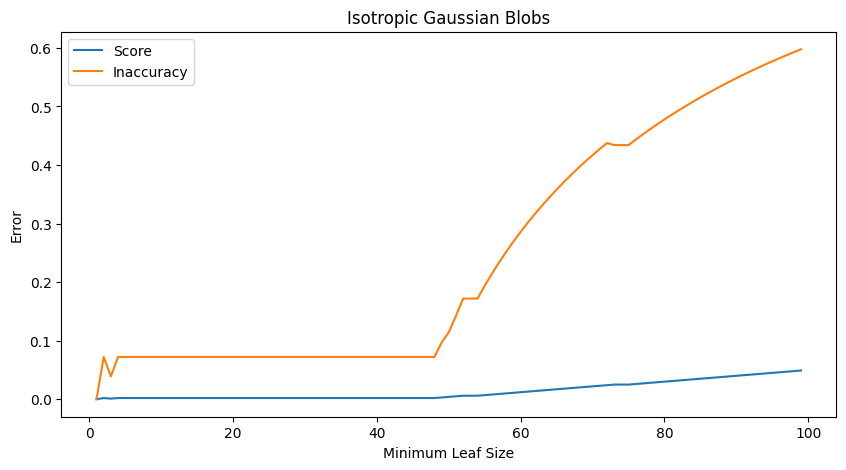

In [26]:
plt.plot(depth, score, label="Score")
plt.plot(depth, inacc, label="Inaccuracy")
plt.title("Isotropic Gaussian Blobs")
plt.ylabel("Error")
plt.xlabel("Minimum Leaf Size")
plt.legend(loc='best')
plt.show()

As we can see, the scoring metric is not able to work with imbalanced datasets, a problem that is not suffered by the new metric of inaccuracy.

## A comparison to precision, recall, F1, ROC AUC

Standard classification metrics evaluate specific operational aspects of prediction, whereas inaccuracy evaluates the amount of information about the target preserved by the predictions. Therefore, inaccuracy can distinguish cases that accuracy, precision, recall, F1, and ROC AUC collapse into the same value.

In [28]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

rng = np.random.default_rng(42)

# Balanced 5-class target
n_per_class = 100
y = np.repeat(np.arange(5), n_per_class)

X_dummy = np.zeros((len(y), 1))

metric = Inaccuracy(y_type="categorical")
metric.fit(X_dummy, y)

,y_type,'categorical'
,n_bins,'auto'
,min_samples_per_cell,5
,min_bins,2
,max_bins,None
,missing,'raise'
,base,2.0
,correction,'none'
,alpha,0.5
,alphabet_size,None


Prediction 1: systematic cyclic permutation for 40% of samples

In [30]:
pred = y.copy()
idx = rng.choice(len(y), size=int(0.4 * len(y)), replace=False)
pred[idx] = (pred[idx] + 1) % 5

In [31]:
print("Accuracy:", accuracy_score(y, pred))
print("Macro precision:", precision_score(y, pred, average="macro"))
print("Macro recall:", recall_score(y, pred, average="macro"))
print("Macro F1:", f1_score(y, pred, average="macro"))
print("Inaccuracy:", metric.inaccuracy_predictions(pred))

Accuracy: 0.6
Macro precision: 0.6002894768883337
Macro recall: 0.6
Macro F1: 0.5997158317491046
Inaccuracy: 0.41712839613851604


Prediction 2: random wrong labels for the same samples

In [32]:
pred = y.copy()
for i in idx:
    alternatives = [c for c in range(5) if c != y[i]]
    pred[i] = rng.choice(alternatives)

In [33]:
print("Accuracy:", accuracy_score(y, pred))
print("Macro precision:", precision_score(y, pred, average="macro"))
print("Macro recall:", recall_score(y, pred, average="macro"))
print("Macro F1:", f1_score(y, pred, average="macro"))
print("Inaccuracy:", metric.inaccuracy_predictions(pred))

Accuracy: 0.6
Macro precision: 0.6008736543902284
Macro recall: 0.6
Macro F1: 0.5995730390467233
Inaccuracy: 0.751677511797614
